***A RNN model for Autocompletion of half typed words.***

The aim of the project is to build a RNN model to suggest autocompletion of half typed words. This comes in many day today applications; typing an email, a text message etc. For example, suppose you type in the four letter "univ", the application may suggest you to autocomplete it by "university".

A RNN is trained to suggest possible autocompletes given  3  -  4  starting letters. That is if the input is string "univ" hopefully we expect to see an output like "university", "universal" etc.
For this we will use a text file (wordlist.txt) containing 10,000 common English words. The list of words will be the "vocabulary" for our model. Python torch library is used to implement the autocomplete model.

In [32]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random


torch.cuda.is_available()

start_time = time.time()

#1: Preparing the vocabulary

In [33]:
WORD_SIZE = 13
with open("wordlist.txt", "r", encoding="utf-8") as f:
    words = [w.strip().lower() for w in f if w.strip()]

filtered_words = [w for w in words if 3 < len(w) <= WORD_SIZE]
vocab = [w.ljust(WORD_SIZE, "_") for w in filtered_words]

len(vocab)

8847

In [34]:
def char_to_num(char):
    if char == "_":
        return 0
    return ord(char) - ord('a') + 1

def num_to_char(num):
    if num == 0:
        return "_"
    return chr(ord('a') + num - 1)

def word_to_numlist(word):
    return torch.tensor([char_to_num(c) for c in word], dtype=torch.long)

def numlist_to_word(numlist):
    return ''.join(num_to_char(int(n)) for n in numlist)

#2: Implementing the Autocomplete model

In [35]:
LEARNING_RATE = 0.005

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [36]:
class autocompleteModel(nn.Module):

    #Constructor
    def __init__(self, alphabet_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()

        #Set the input parameters to self parameters
        self.alphabet_size = alphabet_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        #Initialize the layers in the model:
        #1 embedding layer, 1 - LSTM cell (hidden layer), 1 fully connected layer with linear activation
        self.embedding = nn.Embedding(alphabet_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, alphabet_size)

        self.to(self.device)

    #Feedforward
    def forward(self, character, hidden_state, cell_state):

        #Perform feedforward in order
        #1. Embed the input (one charcter represented by a number)
        #2. Feed the embedded output to the LSTM cell
        #3. Feed the LSTM output to the fully connected layer to obtain the output
        #4. return the output, and both the hidden state and cell state from the LSTM cell output

        x = character.view(1, 1).to(self.device)
        emb = self.embedding(x)
        lstm_out, (h, c) = self.lstm(emb, (hidden_state, cell_state))
        logits = self.fc(lstm_out.squeeze(0).squeeze(0))
        return logits, h, c

    #Intialize the first hidden state and cell state (for the start of a word) as zero tensors of required length.
    def initial_state(self, batch_size=1):

        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=self.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=self.device)

        return (h0, c0)

    #Train the model in epochs given the vocab, the training will be fed in batches of batch_size
    def trainModel(self, vocab, epochs=5, batch_size=100):

        #Convert the model into train mode
        self.train()

        #Set the optimizer (ADAM)
        optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        criterion = nn.CrossEntropyLoss()

        #Pre-tensorize vocab once
        vocab_tensors = torch.stack([word_to_numlist(w) for w in vocab]).to(self.device)  # (N, WORD_SIZE)
        N = vocab_tensors.size(0)
        num_iter = math.ceil(N / batch_size)

        #Keep a log of the loss at the end of each training cycle.
        loss_log = []

        for e in range(epochs):
            epoch_loss = []

            #Shuffle the vocab list the start of each epoch
            perm = torch.randperm(N, device=self.device)
            vocab_shuffled = vocab_tensors[perm]

            for i in range(num_iter):
                start = i * batch_size
                end = min((i + 1) * batch_size, N)
                batch = vocab_shuffled[start:end]

                inputs  = batch[:, :-1].long()
                targets = batch[:,  1:].long()

                optimizer.zero_grad()
                emb = self.embedding(inputs)
                lstm_out, _ = self.lstm(emb)
                logits = self.fc(lstm_out)
                loss = criterion(logits.reshape(-1, self.alphabet_size),
                                 targets.reshape(-1))
                loss.backward()
                optimizer.step()

                loss_log.append(loss.detach().item())
                epoch_loss.append(loss.detach().item())

            # quick check each epoch
            print(f"Epoch {e + 1}/{epochs}  |  Avg Loss: {(sum(epoch_loss) / len(epoch_loss)):.4f}")

        if len(loss_log) > 1:
            plt.figure()
            plt.plot(loss_log)
            plt.xlabel("Training step (batches)")
            plt.ylabel("Avg cross-entropy loss")
            plt.title("Training loss")
            plt.show()

    #Perform autocmplete given a sample of strings
    def autocomplete(self, sample, temperature = 0.3, greedy=True):

        #Convert the model into evaluation mode
        self.eval()
        completed_list = []

        #In the following loop for each sample item initialize hidden and cell states, then predict the remaining characters
        with torch.no_grad():
            for literal in sample:
                # clamp prefix length and lowercase
                prefix = (literal or "").lower()[:WORD_SIZE]

                # initialize hidden and cell states
                h, c = self.initial_state(1)
                logits = None

                # warm-up the LSTM with the known prefix
                for ch in prefix:
                    x = torch.tensor(char_to_num(ch), device=self.device).long()
                    logits, h, c = self.forward(x, h, c)

                generated = list(prefix)

                # predict remaining characters up to WORD_SIZE
                for _ in range(WORD_SIZE - len(prefix)):
                    # if produced an underscore, keep padding underscores
                    if len(generated) > 0 and generated[-1] == "_":
                        x = torch.tensor(char_to_num("_"), device=self.device).long()
                        logits, h, c = self.forward(x, h, c)
                        generated.append("_")
                        continue

                    # if no logits yet, seed with underscore
                    if logits is None:
                        x = torch.tensor(char_to_num("_"), device=self.device).long()
                        logits, h, c = self.forward(x, h, c)

                    if greedy:
                        idx = torch.argmax(logits, dim=-1)
                    else:
                        probs = torch.softmax(logits / temperature, dim=-1)
                        idx = torch.multinomial(probs, 1)
                    ch = num_to_char(int(idx.item()))
                    generated.append(ch)

                    # feed sampled char back in
                    logits, h, c = self.forward(idx.long().to(self.device), h, c)

                completed_list.append(''.join(generated))

        return(completed_list)

    def evaluate(self, test_samples):
        try:
            completions = self.autocomplete(test_samples)
            score = 0
            print("Evaluation Results:")
            for sample, completion in zip(test_samples, completions):
                clean_completion = completion.rstrip('_')
                sample_score = 1 if any(word.rstrip('_').lower() == clean_completion.lower()
                                        for word in vocab) else 0
                mark = "✓ Valid word" if sample_score else "✗ Not in vocab"
                print(f"  '{sample}' -> '{clean_completion}' {mark}")
                score += sample_score
            return score, completions
        except Exception as e:
            print(f"Error during evaluation: {e}")
            return 0, []


#3: Using and evaluating the model


In [37]:
EMBED_DIM = 100
HIDDEN_SIZE = 128
LEARNING_RATE = 0.005
EPOCHS = 60
BATCH_SIZE = 256

test_samples = [
    "comp", "prog", "soft", "data", "algo", "code", "web", "net", "sys", "hack",
    "math", "calc", "stat", "phys", "chem", "biol", "theo", "exp", "res", "lab",
    "engin", "mech", "elec", "civil", "aero", "aut", "robo", "desi", "bui", "tool",
    "mana", "lead", "team", "proj", "plan", "str", "mark", "sale", "cust", "serv",
    "univ", "stud", "lear", "educ", "sch", "grad", "degr", "cour", "exam", "tes",
    "medi", "heal", "nur", "doct", "hosp", "drug", "ther", "tre", "diag", "surg",
    "arti", "des", "musi", "pain", "draw", "writ", "poet", "danc", "sin", "acto",
]

Training model...
Epoch 1/60  |  Avg Loss: 1.6538
Epoch 2/60  |  Avg Loss: 1.2996
Epoch 3/60  |  Avg Loss: 1.2055
Epoch 4/60  |  Avg Loss: 1.1503
Epoch 5/60  |  Avg Loss: 1.1107
Epoch 6/60  |  Avg Loss: 1.0757
Epoch 7/60  |  Avg Loss: 1.0465
Epoch 8/60  |  Avg Loss: 1.0212
Epoch 9/60  |  Avg Loss: 0.9960
Epoch 10/60  |  Avg Loss: 0.9717
Epoch 11/60  |  Avg Loss: 0.9520
Epoch 12/60  |  Avg Loss: 0.9304
Epoch 13/60  |  Avg Loss: 0.9146
Epoch 14/60  |  Avg Loss: 0.8986
Epoch 15/60  |  Avg Loss: 0.8813
Epoch 16/60  |  Avg Loss: 0.8684
Epoch 17/60  |  Avg Loss: 0.8556
Epoch 18/60  |  Avg Loss: 0.8414
Epoch 19/60  |  Avg Loss: 0.8291
Epoch 20/60  |  Avg Loss: 0.8184
Epoch 21/60  |  Avg Loss: 0.8070
Epoch 22/60  |  Avg Loss: 0.7976
Epoch 23/60  |  Avg Loss: 0.7860
Epoch 24/60  |  Avg Loss: 0.7792
Epoch 25/60  |  Avg Loss: 0.7712
Epoch 26/60  |  Avg Loss: 0.7632
Epoch 27/60  |  Avg Loss: 0.7559
Epoch 28/60  |  Avg Loss: 0.7490
Epoch 29/60  |  Avg Loss: 0.7424
Epoch 30/60  |  Avg Loss: 0.7361
E

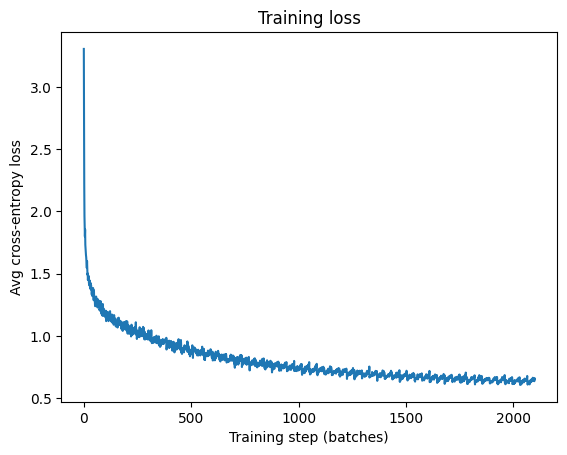


Evaluating model...
Evaluation Results:
  'comp' -> 'comparison' ✓ Valid word
  'prog' -> 'program' ✓ Valid word
  'soft' -> 'soft' ✓ Valid word
  'data' -> 'data' ✓ Valid word
  'algo' -> 'algorithm' ✓ Valid word
  'code' -> 'code' ✓ Valid word
  'web' -> 'website' ✓ Valid word
  'net' -> 'network' ✓ Valid word
  'sys' -> 'systematic' ✓ Valid word
  'hack' -> 'hacker' ✓ Valid word
  'math' -> 'mathematic' ✗ Not in vocab
  'calc' -> 'calculators' ✓ Valid word
  'stat' -> 'statute' ✓ Valid word
  'phys' -> 'physician' ✓ Valid word
  'chem' -> 'chemical' ✓ Valid word
  'biol' -> 'biology' ✓ Valid word
  'theo' -> 'theore' ✗ Not in vocab
  'exp' -> 'experience' ✓ Valid word
  'res' -> 'reservation' ✓ Valid word
  'lab' -> 'label' ✓ Valid word
  'engin' -> 'engineer' ✓ Valid word
  'mech' -> 'mechanics' ✓ Valid word
  'elec' -> 'electronic' ✓ Valid word
  'civil' -> 'civilian' ✓ Valid word
  'aero' -> 'aeropher' ✗ Not in vocab
  'aut' -> 'automobile' ✓ Valid word
  'robo' -> 'robot' ✓ Val

In [38]:
model = autocompleteModel(
    alphabet_size=27,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE
)

print("Training model...")
model.trainModel(vocab, epochs=EPOCHS, batch_size=BATCH_SIZE)

print("\nEvaluating model...")
score, completions = model.evaluate(test_samples)

print(f"\nTotal Score: {score}/{len(test_samples)}")
print(f"Average Score per Sample: {score/len(test_samples):.2f}")

In [39]:
end_time = time.time()

print(f"Execution time: {end_time - start_time:.4f} seconds")

Execution time: 155.7645 seconds
